In [57]:
"""
add_reference_rmsd -- notebook version
======================================
Superpose design chain A residues LO-HI onto the reference chain A, then measure
RMSD of the design binder (chain B) vs the reference binder with NO further fitting.
Writes RefBinder_RMSD / RefRMSD_Source back into the stats CSVs.

Edit the CONFIG block below, then run the cell.
"""
from __future__ import annotations

import glob
import os

import numpy as np
import pandas as pd

# ========================= CONFIG -- EDIT ME ============================== #
DESIGN_PATH = "/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_29_balm_deployed_weight_10_length_15/"          # folder holding the CSVs
REF_PDB     = "/FastHome/gyula/designs/Notable/best.pdb"  # reference structure

ALIGN_CHAIN  = "A"     # target chain used for superposition
ALIGN_LO     = 15      # first target residue of the alignment window
ALIGN_HI     = 166     # last  target residue of the alignment window
BINDER_CHAIN = "B"     # chain whose RMSD is reported

SUBDIRS = [ "Accepted"]     # searched for PDBs
CSV_NAMES = [
    "mpnn_design_stats.csv",
    "final_design_stats.csv",
    "mpnn_design_stats_augmented.csv",
    "mpnn_design_stats_augmented_with_ntoc.csv",
]
DRY_RUN = False        # True = print only, don't write the CSVs
# ========================================================================== #

RMSD_COL, SRC_COL = "RefBinder_RMSD", "RefRMSD_Source"


# --------------------------------------------------------------------------- #
# minimal PDB reader                                                           #
# --------------------------------------------------------------------------- #
def read_ca(pdb_path, chain, lo=None, hi=None, first_model_only=True):
    """{resseq: xyz} for CA atoms of `chain`, optionally restricted to [lo, hi].

    Stops at the first ENDMDL so a multi-model trajectory PDB doesn't overwrite
    earlier models with later ones.
    """
    out = {}
    with open(pdb_path, "r", errors="replace") as fh:
        for line in fh:
            if first_model_only and line.startswith("ENDMDL"):
                break
            if not line.startswith("ATOM"):
                continue
            if line[12:16].strip() != "CA":
                continue
            if line[21] != chain:
                continue
            if line[16] not in (" ", "A"):          # keep one altloc only
                continue
            try:
                resseq = int(line[22:26])
                xyz = (float(line[30:38]), float(line[38:46]), float(line[46:54]))
            except ValueError:
                continue
            if lo is not None and not (lo <= resseq <= hi):
                continue
            out.setdefault(resseq, np.array(xyz))
    return out


def kabsch(P, Q):
    """Rotation+translation taking P onto Q (both (N,3)). Returns (R, t)."""
    Pc, Qc = P.mean(0), Q.mean(0)
    H = (P - Pc).T @ (Q - Qc)
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    R = Vt.T @ np.diag([1.0, 1.0, d]) @ U.T     # reflection guard
    return R, Qc - R @ Pc


_REF_CACHE = {}


def reference_binder_rmsd(design_pdb, ref_pdb=None, align_chain=None,
                          lo=None, hi=None, binder_chain=None):
    """RMSD of design binder vs reference binder after superposing on the target.

    Returns (rmsd, n_align, n_binder, note); rmsd is None if it could not be done.
    Defaults come from the CONFIG block, so re-running a cell picks up edits.
    """
    ref_pdb      = REF_PDB      if ref_pdb      is None else ref_pdb
    align_chain  = ALIGN_CHAIN  if align_chain  is None else align_chain
    lo           = ALIGN_LO     if lo           is None else lo
    hi           = ALIGN_HI     if hi           is None else hi
    binder_chain = BINDER_CHAIN if binder_chain is None else binder_chain

    key = (ref_pdb, align_chain, lo, hi, binder_chain)
    if key not in _REF_CACHE:
        _REF_CACHE[key] = (read_ca(ref_pdb, align_chain, lo, hi),
                           read_ca(ref_pdb, binder_chain))
    ref_a, ref_b = _REF_CACHE[key]
    if not ref_a:
        return None, 0, 0, f"reference has no chain {align_chain} in {lo}-{hi}"
    if not ref_b:
        return None, 0, 0, f"reference has no chain {binder_chain}"

    des_a = read_ca(design_pdb, align_chain, lo, hi)
    des_b = read_ca(design_pdb, binder_chain)
    if not des_a:
        return None, 0, 0, f"design has no chain {align_chain} in {lo}-{hi}"
    if not des_b:
        return None, 0, 0, f"design has no chain {binder_chain}"

    # align on residue NUMBERS present in both -- robust to gaps/missing residues
    common = sorted(set(ref_a) & set(des_a))
    if len(common) < 3:
        return None, len(common), 0, "fewer than 3 shared target residues"
    P = np.array([des_a[i] for i in common])
    Q = np.array([ref_a[i] for i in common])
    R, t = kabsch(P, Q)

    # binder: pair by residue number if they match, else by order along the chain
    bd, br = sorted(des_b), sorted(ref_b)
    note = ""
    shared = sorted(set(bd) & set(br))
    if len(shared) == len(bd) == len(br):
        D  = np.array([des_b[i] for i in shared])
        Rf = np.array([ref_b[i] for i in shared])
    else:
        n = min(len(bd), len(br))
        if len(bd) != len(br):
            note = f"binder length differs ({len(bd)} vs {len(br)}); compared first {n}"
        D  = np.array([des_b[i] for i in bd[:n]])
        Rf = np.array([ref_b[i] for i in br[:n]])

    D_moved = (R @ D.T).T + t                  # design binder into reference frame
    rmsd = float(np.sqrt(((D_moved - Rf) ** 2).sum(-1).mean()))
    rev_rmsd = float(np.sqrt(((D_moved - Rf[::-1]) ** 2).sum(-1).mean()))

    rmsd = min(rmsd,rev_rmsd)
    return round(rmsd, 2), len(common), len(D), note


# --------------------------------------------------------------------------- #
# CSV wiring                                                                   #
# --------------------------------------------------------------------------- #
def index_pdbs(design_path, subdirs):
    """{filename stem: full path} for every PDB under the given subfolders."""
    found = {}
    for sub in subdirs:
        root = os.path.join(design_path, sub)
        if not os.path.isdir(root):
            continue
        for p in glob.glob(os.path.join(root, "**", "*.pdb"), recursive=True):
            found.setdefault(os.path.splitext(os.path.basename(p))[0], p)
    return found


def match_pdb(design_name, pdb_index):
    """Prefer the exact stem; otherwise the shortest (least decorated) filename
    containing the design name, so the plain Accepted copy beats a ranked one."""
    if design_name in pdb_index:
        return pdb_index[design_name]
    hits = [p for stem, p in pdb_index.items() if design_name in stem]
    return min(hits, key=lambda p: len(os.path.basename(p))) if hits else None


def process_csv(csv_path, pdb_index, dry_run=False):
    if not os.path.exists(csv_path):
        print(f"  {os.path.basename(csv_path)}: not found, skipping")
        return None
    df = pd.read_csv(csv_path)
    if "Design" not in df.columns:
        print(f"  {os.path.basename(csv_path)}: no 'Design' column, skipping")
        return None

    rmsds, srcs, missing, failed = [], [], 0, 0
    for name in df["Design"].astype(str):
        pdb = match_pdb(name, pdb_index)
        if pdb is None:
            rmsds.append(np.nan)
            srcs.append("")
            missing += 1
            continue
        val, na, nb, note = reference_binder_rmsd(pdb)
        if val is None:
            failed += 1
            if failed <= 3:
                print(f"    {name}: {note}")
        rmsds.append(val if val is not None else np.nan)
        srcs.append(pdb)
    df[RMSD_COL] = rmsds
    df[SRC_COL] = srcs

    vals = pd.to_numeric(df[RMSD_COL], errors="coerce").dropna()
    rng = f", range {vals.min():.2f}-{vals.max():.2f} A" if len(vals) else ""
    print(f"  {os.path.basename(csv_path)}: {len(df)} rows, {len(vals)} measured, "
          f"{missing} no PDB found, {failed} failed{rng}")
    if not dry_run:
        df.to_csv(csv_path, index=False)
    return df


def run(design_path=None, ref_pdb=None, dry_run=None):
    """Run the whole thing. Returns {csv_name: DataFrame} for inspection."""
    design_path = DESIGN_PATH if design_path is None else design_path
    ref_pdb     = REF_PDB     if ref_pdb     is None else ref_pdb
    dry_run     = DRY_RUN     if dry_run     is None else dry_run

    if not os.path.exists(ref_pdb):
        raise FileNotFoundError(f"reference not found: {ref_pdb}")
    if not os.path.isdir(design_path):
        raise NotADirectoryError(f"design_path not found: {design_path}")

    ref_a = read_ca(ref_pdb, ALIGN_CHAIN, ALIGN_LO, ALIGN_HI)
    ref_b = read_ca(ref_pdb, BINDER_CHAIN)
    print(f"reference {ref_pdb}")
    print(f"  chain {ALIGN_CHAIN} {ALIGN_LO}-{ALIGN_HI}: {len(ref_a)} CA   "
          f"chain {BINDER_CHAIN}: {len(ref_b)} CA")

    pdb_index = index_pdbs(design_path, SUBDIRS)
    print(f"indexed {len(pdb_index)} PDBs under {', '.join(SUBDIRS)}")
    if not pdb_index:
        raise RuntimeError("no PDBs found -- check SUBDIRS / DESIGN_PATH")

    results = {}
    for csv_name in CSV_NAMES:
        out = process_csv(os.path.join(design_path, csv_name), pdb_index, dry_run)
        if out is not None:
            results[csv_name] = out
    if dry_run:
        print("\n(dry run -- nothing written)")
    return results


for run_i in runs:
    run(design_path = f"/FastHome/gyula/designs/place_holder/DATA/{run_i}")

reference /FastHome/gyula/designs/Notable/best.pdb
  chain A 15-166: 152 CA   chain B: 15 CA
indexed 206 PDBs under Accepted


/tmp/ipykernel_1191622/1555978598.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[RMSD_COL] = rmsds
/tmp/ipykernel_1191622/1555978598.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[SRC_COL] = srcs


  mpnn_design_stats.csv: 545 rows, 103 measured, 442 no PDB found, 0 failed, range 4.76-13.20 A


/tmp/ipykernel_1191622/1555978598.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[RMSD_COL] = rmsds
/tmp/ipykernel_1191622/1555978598.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[SRC_COL] = srcs


  final_design_stats.csv: 103 rows, 103 measured, 0 no PDB found, 0 failed, range 4.76-13.20 A


...

  final_design_stats.csv: 108 rows, 108 measured, 0 no PDB found, 0 failed, range 0.55-14.72 A


/tmp/ipykernel_1191622/1555978598.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[RMSD_COL] = rmsds
/tmp/ipykernel_1191622/1555978598.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[SRC_COL] = srcs


  mpnn_design_stats_augmented.csv: 324 rows, 108 measured, 216 no PDB found, 0 failed, range 0.55-14.72 A


/tmp/ipykernel_1191622/1555978598.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[RMSD_COL] = rmsds
/tmp/ipykernel_1191622/1555978598.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[SRC_COL] = srcs


  mpnn_design_stats_augmented_with_ntoc.csv: 324 rows, 108 measured, 216 no PDB found, 0 failed, range 0.55-14.72 A
reference /FastHome/gyula/designs/Notable/best.pdb
  chain A 15-166: 152 CA   chain B: 15 CA
indexed 204 PDBs under Accepted
  mpnn_design_stats.csv: 725 rows, 104 measured, 621 no PDB found, 0 failed, range 0.00-10.53 A
  final_design_stats.csv: 102 rows, 102 measured, 0 no PDB found, 0 failed, range 0.00-10.53 A
  mpnn_design_stats_augmented.csv: 725 rows, 104 measured, 621 no PDB found, 0 failed, range 0.00-10.53 A
  mpnn_design_stats_augmented_with_ntoc.csv: 725 rows, 104 measured, 621 no PDB found, 0 failed, range 0.00-10.53 A


In [16]:
import pandas as pd
df = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_29_balm_deployed_weight_10_length_15/mpnn_design_stats_augmented_with_ntoc.csv")

In [3]:
df.RefBinder_RMSD

0        NaN
1        NaN
2       6.39
3        NaN
4       5.93
        ... 
1990     NaN
1991     NaN
1992     NaN
1993    7.16
1994    7.12
Name: RefBinder_RMSD, Length: 1995, dtype: float64

In [15]:
df.delta_total

AttributeError: 'DataFrame' object has no attribute 'delta_total'

In [58]:
df = df[~df['Design'].str.startswith('BAX_1F16_l15_s333315_', na=False)]

<Axes: xlabel='RefBinder_RMSD', ylabel='delta_total'>

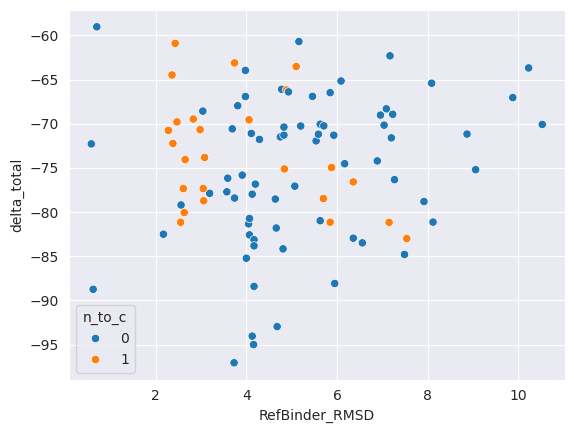

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(df, x ="RefBinder_RMSD", y="delta_total", hue = "n_to_c")

Text(0, 0.5, 'density')

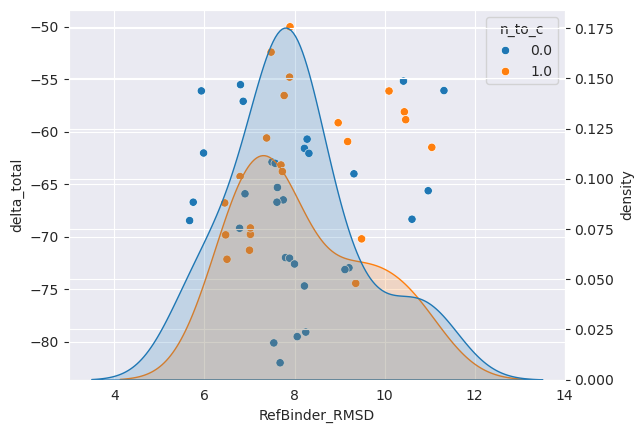

In [67]:
ax = sns.scatterplot(data=df_all, x="RefBinder_RMSD", y="delta_total", hue="n_to_c")
ax2 = ax.twinx()
sns.kdeplot(data=df_all, x="RefBinder_RMSD", hue="n_to_c", ax=ax2,
            fill=True, alpha=0.2, legend=False)
ax2.set_ylabel("density")

In [64]:
runs = ["gy_0", "gy_2", "gy_4", "gy_5", "gy_7", "gy_11_mut_5", "gy_13_maybe_mut_20",
        "gy_14_more_iter", "j_1", "gy_2nd_iter_1",
        "gy_2nd_iter_try_23_balm_deployed",
        "gy_2nd_iter_try_24_control_interface_fixing",
        "gy_2nd_iter_try_29_balm_deployed_weight_10_length_15"]

base = "/FastHome/gyula/designs/place_holder/DATA"

df_all = pd.concat(
    [pd.read_csv(f"{base}/{r}/mpnn_design_stats_augmented_with_ntoc.csv").assign(run=r)
     for r in runs],
    ignore_index=True,
)
df_all.shape

/tmp/ipykernel_1191622/913891036.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  [pd.read_csv(f"{base}/{r}/mpnn_design_stats_augmented_with_ntoc.csv").assign(run=r)


(5961, 252)

In [65]:
df_all = df_all.dropna(subset ="delta_total")
df_all.shape

(1640, 252)

In [50]:
key = df_all["Design"].str.rsplit("_", n=1).str[0]
df_all = df_all[~key.duplicated()]


In [66]:
df_all.shape
df_all = df_all.loc[df_all.Length ==15,]

Text(0, 0.5, 'MM/PBSA (kcal/mol)')

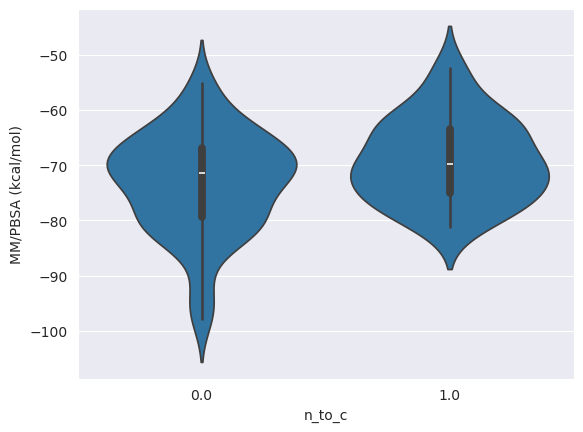

In [53]:
sns.violinplot(df_all, x = "n_to_c", y = "delta_total")
plt.ylabel("MM/PBSA (kcal/mol)")

In [52]:
df_all.delta_total.min()

np.float64(-97.76)

In [55]:
df_all.n_to_c.value_counts()

n_to_c
0.0    71
1.0    29
Name: count, dtype: int64

In [54]:
from scipy import stats

groups = [g["delta_total"].dropna().values for _, g in df_all.groupby("n_to_c")]
print(df_all.groupby("n_to_c")["delta_total"].agg(["count", "mean", "std"]))

if len(groups) == 2:
    t, p = stats.ttest_ind(*groups, equal_var=False)   # Welch
    print(f"Welch t = {t:.3f}, p = {p:.3g}")
else:
    f, p = stats.f_oneway(*groups)
    print(f"ANOVA F = {f:.3f}, p = {p:.3g}")

        count       mean       std
n_to_c                            
0.0        71 -73.218732  9.205980
1.0        29 -69.098276  7.480206
Welch t = -2.332, p = 0.0229
